In [96]:
import pandas as pd


# Load the CSV file into a DataFrame
df = pd.read_csv('/Users/emretoner/Desktop/surveyresults.csv')

# Display the first few rows to confirm it's loaded
df.head()

,Timestamp,Email Address,Volunteer Name\nNom du Volontaire,Sector \nSecteur,Region\nRégion,Prefecture\nPréfecture,Sub-prefecture\nsous-préfecture,Village/Site\nVillage,Has your Subprefecture completed a mosquito net distribution campaign?\nVotre sous-préfecture a-t-elle réalisé une campagne de distribution de moustiquaires ?,Date of survey\nDate de l'enquête,...,Total number of nets received as a gift / Nombre total de moustiquaires reçues en cadeau:,Total number of nets received from other sources / Nombre total de moustiquaires reçues d'autres sources:,Were the majority of the nets square or round? / La plupart des moustiquaires étaient-ils carrés ou ronds ?,What was the average cost of all nets in the household? / Quel était le coût moyen de toutes les moustiquaires du ménage ?,How many men live in the house?\nCombien d'hommes vivent dans la maison ?,How many women live in the house?\nCombien de femmes vivent dans la maison ?,How many pregnant women live in the house?\nCombien de femmes enceintes vivent dans la maison ?,"Last night, how many adults slept under a mosquito net?\nLa nuit dernière, combien d’adultes dans cette maison ont dormi sous une moustiquaire ?\n","Last night, how many children slept under a mosquito net in this house?\nLa nuit dernière, combien d’enfants ont dormi sous une moustiquaire dans cette maison ?",Column 104
0,5/6/2025 11:02:42,afidobson@gmail.com,Afi,PH,Labe,Labe,Garambe,Labedheppere,No,5/6/2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5/6/2025 11:08:44,afidobson@gmail.com,Afi,PH,Labe,Labe,Garambe,Labedheppere,No,5/6/2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5/6/2025 11:13:59,afidobson@gmail.com,Afi,PH,Labe,Labe,Garambe,Labedheppere,No,5/6/2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5/6/2025 11:23:07,afidobson@gmail.com,Afi,PH,Labe,Labe,Garambe,Labedheppere,No,5/6/2025,...,0.0,0.0,Round/Rond,Free,NaN,NaN,NaN,NaN,NaN,NaN
4,5/6/2025 11:29:01,afidobson@gmail.com,Afi,PH,Labe,Labe,Garambe,Labedheppere,No,5/6/2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
# Create a list of columns to clean
cols_to_fix = ['Prefecture\nPréfecture','Sub-prefecture\nsous-préfecture', 'Village/Site\nVillage']

for col in cols_to_fix:
    # 1. Convert to string (to handle any accidental NaNs or numbers)
    # 2. Strip leading/trailing whitespace
    # 3. Replace multiple internal spaces with a single space
    # 4. Convert to Title Case (e.g., 'KOROUSSA' or 'koroussa' -> 'Koroussa')
    df[col] = df[col].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True).str.title()
unique_locations = df[['Prefecture\nPréfecture','Sub-prefecture\nsous-préfecture', 'Village/Site\nVillage']].drop_duplicates()

# Sort them alphabetically for a cleaner view
unique_locations = unique_locations.sort_values(['Prefecture\nPréfecture','Sub-prefecture\nsous-préfecture', 'Village/Site\nVillage'])


In [83]:
unique = list(set(unique_locations.iloc[:, 0]))
unique

['Dabola',
 'Mamou',
 'Popodara',
 'Labe',
 'Nan',
 'Dalaba',
 'Lélouma',
 'Lelouma',
 'Boke']

Success! Map saved to /Users/emretoner/Desktop/Guinea_Study_Map_Campaigns.png


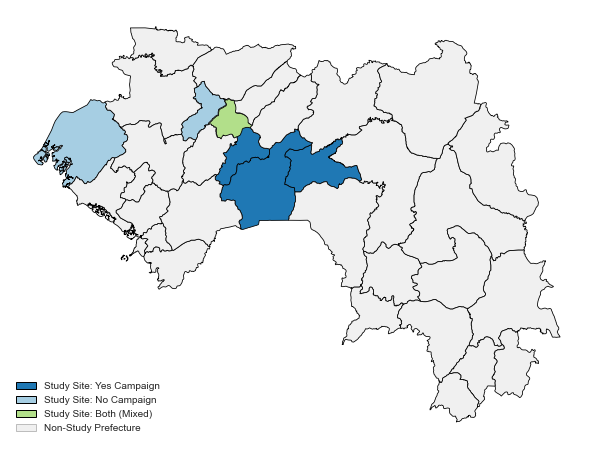

In [84]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch

# 1. Load the data
path_to_json = "gadm41_GIN_2.json" 

try:
    guinea = gpd.read_file(path_to_json, engine='pyogrio')
    
    # 2. Define our groups
    no_campaign = ['Lélouma', 'Boké']
    yes_campaign = ['Dalaba', 'Dabola', 'Mamou']
    both_campaign = ['Labé']
    
    # 3. Create a Categorization Column
    def categorize(name):
        if name in no_campaign:
            return 'Study: No Campaign'
        if name in yes_campaign:
            return 'Study: Yes Campaign'
        if name in both_campaign:
            return 'Study: Both (Mixed)'
        return 'Non-Study Area'

    guinea['category'] = guinea['NAME_2'].apply(categorize)

    # 4. Define Professional Grayscale-Friendly Colors
    # Using a mix of blues and a neutral for the "Both" category
    color_map = {
        'Study: No Campaign': '#a6cee3', # Light Blue
        'Study: Yes Campaign': '#1f78b4', # Dark Blue
        'Study: Both (Mixed)': '#b2df8a',  # Soft Green (distinct but harmonious)
        'Non-Study Area': '#f0f0f0'        # Light Grey
    }

    # 5. Create Figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Plot each category
    for cat, color in color_map.items():
        guinea[guinea['category'] == cat].plot(
            ax=ax, 
            color=color, 
            edgecolor='black' if 'Study' in cat else '#bdbdbd', 
            linewidth=0.8 if 'Study' in cat else 0.4
        )

    # 6. Create Custom Legend
    legend_elements = [
        Patch(facecolor='#1f78b4', edgecolor='black', label='Study Site: Yes Campaign'),
        Patch(facecolor='#a6cee3', edgecolor='black', label='Study Site: No Campaign'),
        Patch(facecolor='#b2df8a', edgecolor='black', label='Study Site: Both (Mixed)'),
        Patch(facecolor='#f0f0f0', edgecolor='#bdbdbd', label='Non-Study Prefecture')
    ]
    ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10)

    # 7. Styling
    ax.set_axis_off()
    
    # 8. Save
    desktop_path = os.path.expanduser('~/Desktop/Guinea_Study_Map_Campaigns.png')
#     plt.savefig(desktop_path, dpi=300, bbox_inches='tight')
    
    print(f"Success! Map saved to {desktop_path}")
    plt.show()

except Exception as e:
    print(f"Error: {e}")

In [97]:
old_total_adult = df.columns[18]
old_total_child = df.columns[19]
old_total_adult

"How many adults live in your house?\nCombien d'adultes vivent dans votre maison ?"

In [99]:
# Rename the column to "campaign"
df.rename(columns={
    "Has your Subprefecture completed a mosquito net distribution campaign?\nVotre sous-préfecture a-t-elle réalisé une campagne de distribution de moustiquaires ?": "campaign"
}, inplace=True)

df = df.rename(columns={
    "How many children under the age of 5 live in your house?\nCombien d'enfants de moins de 5 ans vivent dans votre maison ?": "total_under_5"
})

df = df.rename(columns={
    "Last night, how many children < five in your family slept under a mosquito net?\nHier soir, combien d'enfants < cinq ans de votre famille ont dormi sous une moustiquaire ?": "under_5_lastnight"
})

df.rename(columns={
    "Are mosquito nets available at the health center?\nEst-ce qu’il y a des moustiquaires au centre de santé?": "available_hc",
    "Are mosquito nets available at the market?\nEst-ce qu’il y a des moustiquaires au marché ?": "available_mkt"
}, inplace=True)

df = df.rename(columns={
    "How many beds or sleeping areas are there in your household?\nCombien de lits ou couchettes y a- il dans votre maison?": "#beds"
})

df.rename(columns={
    "Total number of nets / Nombre total de moustiquaires:": "# of nets",
    old_total_adult: 'total_adult_house',
    old_total_child: 'total_child_house',
    "Total number of nets hung / Nombre total de moustiquaires suspendues:": "# nets hung",
    "Total number of nets still in packaging / Nombre total de moustiquaires encore dans l'emballage:": "# unused",
    "Total number of nets received from health facility / Nombre total de moustiquaires reçues du centre/poste de santé": "# from clinic",
    "Total number of nets purchased at the regional market/Conakry / Nombre total de moustiquaires achetées au marché régional/ à Conakry:": "# purchased",
    "Total number of nets received from other sources / Nombre total de moustiquaires reçues d'autres sources:": "# other",
    "Total number of nets received from free distribution / Nombre total de moustiquaires reçues de la distribution gratuite:": "# free distribution"
}, inplace=True)

renamed_cols = [
    "# of nets",
    "# nets hung",
    "# unused",
    "# from clinic",
    "# purchased",
    "# other",
    "# free distribution"
]

# Fill NaNs with 0 in these columns
df[renamed_cols] = df[renamed_cols].fillna(0)

# Optional: check that it worked
print(df.columns)

Index(['Timestamp', 'Email Address', 'Volunteer Name\nNom du Volontaire',
       'Sector \nSecteur', 'Region\nRégion', 'Prefecture\nPréfecture',
       'Sub-prefecture\nsous-préfecture', 'Village/Site\nVillage', 'campaign',
       'Date of survey\nDate de l'enquête',
       ...
       'Total number of nets received as a gift / Nombre total de moustiquaires reçues en cadeau:',
       '# other',
       'Were the majority of the nets square or round? / La plupart des moustiquaires étaient-ils carrés ou ronds ?',
       'What was the average cost of all nets in the household? / Quel était le coût moyen de toutes les moustiquaires du ménage ?',
       'How many men live in the house?\nCombien d'hommes vivent dans la maison ?',
       'How many women live in the house?\nCombien de femmes vivent dans la maison ?',
       'How many pregnant women live in the house?\nCombien de femmes enceintes vivent dans la maison ?',
       'Last night, how many adults slept under a mosquito net?\nLa nuit de

Population Access

In [72]:
total_population = df.groupby('campaign', as_index=False).agg(
    total_children=('total_child_house', 'sum'),
    total_adults=('total_adult_house', 'sum')
)

# Then just sum the rows to get the grand total
total_population['total_residents'] = total_population['total_children'] + total_population['total_adults']

In [71]:
total_population

,campaign,total_children,total_adults,total_residents
0,No,623.0,519.0,1142.0
1,Yes,462.0,375.0,837.0


In [66]:
total_population.iloc[0, 3]

1142.0

In [43]:
import numpy as np

total_nets_household = df["# of nets"].fillna(0)
df['total_residents'] = df['total_child_house'] + df['total_adult_house']
df['total_residents'] = df['total_residents'].dropna()
residents = df['total_residents']
df['capped_access'] = np.minimum((total_nets_household * 2),residents).dropna()
potential_users = df.groupby('campaign', as_index=False).agg(total_potential_users = ('capped_access', 'sum'))
potential_users

,campaign,total_potential_users
0,No,237.0
1,Yes,610.0


In [53]:
df['access_ratio'] = df['capped_access']/df['total_residents']

In [77]:
# population access pre-distribution

no_campaign_pop_access = np.round((((potential_users.iloc[0,1])/(total_population.iloc[0, 3]))*100), 1) 
print(f"{no_campaign_pop_access} no campaign population access")
yes_campaign_pop_access = np.round((((potential_users.iloc[1,1])/(total_population.iloc[1, 3]))*100), 1) 
print(f"{yes_campaign_pop_access} yes campaign population access")


20.8 no campaign population access
72.9 yes campaign population access


8.99192309356803e-31 is the pvalue


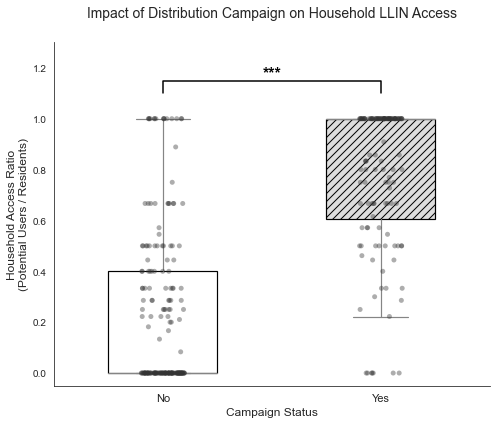

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import os


# 1. Perform the Mann-Whitney U Test
# Ensure no NaNs exist in 'access_ratio' before splitting
df_clean = df.dropna(subset=['access_ratio'])
group_no = df_clean[df_clean['campaign'] == 'No']['access_ratio']
group_yes = df_clean[df_clean['campaign'] == 'Yes']['access_ratio']
u_stat, p_val = mannwhitneyu(group_no, group_yes, alternative='two-sided')
print(f"{p_val} is the pvalue")
# 2. Determine the "star" notation based on p-value
if p_val < 0.001:
    star_text = "***"
elif p_val < 0.01:
    star_text = "**"
elif p_val < 0.05:
    star_text = "*"
else:
    star_text = "ns"

# 3. Create the Visualization (Black and White Style)
plt.figure(figsize=(7, 6))
# Set theme to 'white' for clean look, remove ticks/grids for minimalist aesthetic
sns.set_style("white")

# Plot Boxplot (using grayscale colors)
# We set faces to white/light gray and use black lines
ax = sns.boxplot(x='campaign', y='access_ratio', data=df_clean, 
                 palette=['#FFFFFF', '#DDDDDD'],  # White and Light Gray
                 color='black',                   # Outline color
                 linewidth=1.2,
                 showfliers=False, width=0.5)

# Optional: Add Hatching to the boxes for increased B&W distinction
for i, box in enumerate(ax.artists):
    box.set_edgecolor('black')
    if i == 1: # Apply hatch to 'Yes Campaign' box only
        box.set_hatch('///')

# Plot Stripplot (Grayscale, individual dots)
sns.stripplot(x='campaign', y='access_ratio', data=df_clean, 
              color=".2", # Dark gray/Black
              alpha=0.4, 
              marker='o', # Circle marker
              jitter=True, 
              size=5)

# 4. Add Significance Annotation (The Bracket and Stars)
# Dynamically determine y-max to place bracket slightly above the data
y_max = df_clean['access_ratio'].max()
y, h, col = y_max + 0.1, 0.05, 'k' # Height and shift for the bracket

x1, x2 = 0, 1   # X-axis indices for 'No' and 'Yes'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, star_text, ha='center', va='bottom', color=col, fontsize=16, fontweight='bold')

# 5. Final Polish for Publication
plt.title('Impact of Distribution Campaign on Household LLIN Access', fontsize=14, pad=25)
plt.ylabel('Household Access Ratio\n(Potential Users / Residents)', fontsize=12)
plt.xlabel('Campaign Status', fontsize=12)

# Ensure the ticks align with your groups and have proper formatting
# Using f-strings to include sample sizes (N) if available
# Example: ['No Campaign\n(N=150)', 'Yes Campaign\n(N=166)']
plt.xticks([0, 1], ['No', 'Yes'], fontsize=11)

# Set Y-limit slightly higher than needed for the bracket
plt.ylim(-0.05, y_max + 0.3) 
sns.despine() # Remove top and right spines for a modern look

plt.tight_layout()
desktop_path = os.path.expanduser('~/Desktop/access_significance_plot_bw.png.png')
# plt.savefig(desktop_path,dpi=300)
plt.show()

In [55]:
df_clean = df.dropna(subset=['access_ratio'])

# --- Numerical Takeaway ---
summary = df_clean.groupby('campaign')['access_ratio'].agg(['mean', 'std', 'count']).round(3)
print("Numerical Summary of Access Ratio:")
print(summary)

# Calculate the relative increase
no_mean = summary.loc['No', 'mean']
yes_mean = summary.loc['Yes', 'mean']
increase = ((yes_mean - no_mean) / no_mean) * 100
print(f"\nThe campaign resulted in a {increase:.1f}% relative increase in the household access ratio (p = {p_val:.4f}).")

Numerical Summary of Access Ratio:
           mean    std  count
campaign                     
No        0.234  0.315    187
Yes       0.778  0.290    128

The campaign resulted in a 232.5% relative increase in the household access ratio (p = 0.0000).


In [56]:
# 1. Define the threshold
threshold = 0.80

# 2. Calculate the percentage of households hitting the target for each group
# We group by campaign and check how many households meet or exceed 0.80
target_met = df_clean.groupby('campaign')['access_ratio'].apply(lambda x: (x >= threshold).mean() * 100)

# 3. Extract the values
val_no = target_met.loc['No']
val_yes = target_met.loc['Yes']

print(f"Percentage of 'No Campaign' households reaching 80% access: {val_no:.1f}%")
print(f"Percentage of 'Yes Campaign' households reaching 80% access: {val_yes:.1f}%")

# 4. (Optional) Find the 'Zero Access' reduction mentioned in your text
zero_access = df_clean.groupby('campaign')['access_ratio'].apply(lambda x: (x == 0).mean() * 100)
print(f"\nPercentage of 'No Campaign' households with zero access: {zero_access.loc['No']:.1f}%")
print(f"Percentage of 'Yes Campaign' households with zero access: {zero_access.loc['Yes']:.1f}%")

Percentage of 'No Campaign' households reaching 80% access: 8.6%
Percentage of 'Yes Campaign' households reaching 80% access: 61.7%

Percentage of 'No Campaign' households with zero access: 54.0%
Percentage of 'Yes Campaign' households with zero access: 5.5%


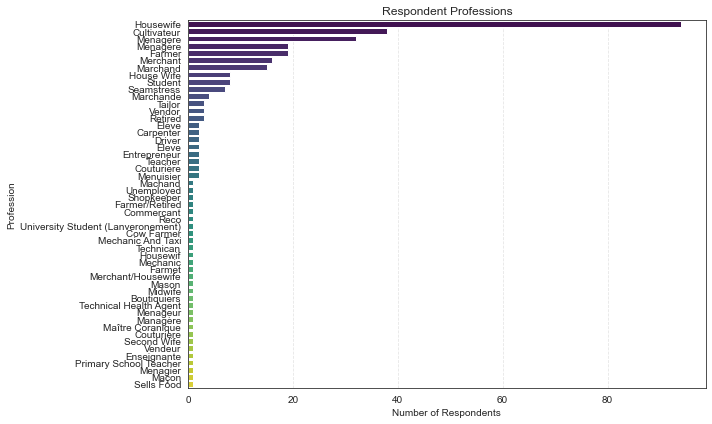

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your actual DataFrame
# df = pd.read_csv("your_data.csv")

# Column name
profession_col = "What is your profession?\nQuelle est votre profession ?"

# Standardize the text: lowercase, strip whitespace, replace known variations
df[profession_col] = df[profession_col].str.strip().str.lower()

# Normalize common variations to "farmer"
df[profession_col] = df[profession_col].replace({
    "farmer": "Farmer",
    "farming": "Farmer",
    "agriculteur": "Farmer",
    "peasant": "Farmer"
})

# Capitalize first letter of each word for clean display
df[profession_col] = df[profession_col].str.title()

# Count responses
profession_counts = df[profession_col].value_counts()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=profession_counts.values, y=profession_counts.index, palette="viridis")
plt.xlabel("Number of Respondents")
plt.ylabel("Profession")
plt.title("Respondent Professions")
plt.grid(axis='x', linestyle='--', alpha=0.5)
desktop_path = os.path.expanduser('~/Desktop/professions.png')
# plt.savefig(desktop_path, facecolor='white', dpi=300)
plt.tight_layout()
plt.show()



In [196]:
# Clean and normalize responses
df["profession_cleaned"] = df["What is your profession?\nQuelle est votre profession ?"] \
    .str.strip().str.lower()

# Map variations to standard categories
df["profession_cleaned"] = df["profession_cleaned"].replace({
    "farmer": "Farmer",
    "farming": "Farmer",
    "agriculteur": "Farmer",
    "peasant": "Farmer",
    "élève": "Student",
    "student": "Student",
    "housewife": "Housewife",
    "ménagère": "Housewife"
    # Add more mappings as needed
})

# Capitalize for display
df["profession_cleaned"] = df["profession_cleaned"].str.title()

# Calculate percentage
profession_percent = df["profession_cleaned"].value_counts(normalize=True) * 100

# Display result
print(profession_percent.round(1).to_string())


Housewife                             35.9
Cultivateur                           12.1
Menagere                              10.2
Farmer                                 6.0
Merchant                               5.1
Marchand                               4.8
Student                                3.2
House Wife                             2.5
Seamstress                             2.2
Marchande                              1.3
Retired                                1.0
Vendor                                 1.0
Tailor                                 1.0
Carpenter                              0.6
Driver                                 0.6
Couturière                             0.6
Entrepreneur                           0.6
Teacher                                0.6
Eleve                                  0.6
Menuisier                              0.6
Machand                                0.3
Midwife                                0.3
Shopkeeper                             0.3
Farmer/Reti

In [197]:
# Filter for rows where campaign is "No"
campaign_no = df[df["campaign"] == "No"]

# Convert availability columns to lowercase strings to standardize
# campaign_no["available_hc"] = campaign_no["available_hc"].str.lower()
# campaign_no["available_mkt"] = campaign_no["available_mkt"].str.lower()

# Compute percentage of "yes" responses
percent_available_hc = (campaign_no["available_hc"] == "Yes/Oui").mean() * 100
percent_available_mkt = (campaign_no["available_mkt"] == "Yes/Oui").mean() * 100

# Display results
print(f"Percentage of households with health center availability (campaign = No): {percent_available_hc:.2f}%")
print(f"Percentage of households with market availability (campaign = No): {percent_available_mkt:.2f}%")


Percentage of households with health center availability (campaign = No): 92.63%
Percentage of households with market availability (campaign = No): 2.11%


In [198]:
# Filter for rows where campaign is "Yes"
campaign_Yes = df[df["campaign"] == "Yes"]

# Convert availability columns to lowercase strings to standardize
# campaign_Yes["available_hc"] = campaign_Yes["available_hc"].str.lower()
# campaign_Yes["available_mkt"] = campaign_Yes["available_mkt"].str.lower()

# Compute percentage of "yes" responses
percent_available_hc = (campaign_Yes["available_hc"] == "Yes/Oui").mean() * 100
percent_available_mkt = (campaign_Yes["available_mkt"] == "Yes/Oui").mean() * 100

# Display results
print(f"Percentage of households with health center availability (campaign = Yes): {percent_available_hc:.2f}%")
print(f"Percentage of households with market availability (campaign = Yes): {percent_available_mkt:.2f}%")


Percentage of households with health center availability (campaign = Yes): 88.28%
Percentage of households with market availability (campaign = Yes): 5.47%


In [199]:
pregnant_yes_count = df[df["Are you pregnant?\nÊtes-vous en état de famille ?"] == "Yes/Oui"].shape[0]
print(f"Number of respondents who said 'Yes/Oui' to pregnancy: {pregnant_yes_count}")


Number of respondents who said 'Yes/Oui' to pregnancy: 21


# UNUSED NETS ANALYSIS


In [71]:
# Sum of unused nets and total nets per campaign group
summary = df.groupby('campaign').agg({
    '# unused': 'sum',
    '# of nets': 'sum'
})

# Calculate percent unused per group
summary['percent_unused'] = (summary['# unused'] / summary['# of nets']) * 100


for campaign, row in summary.iterrows():
    print(f"Percent of nets unused in campaign '{campaign}': {row['percent_unused']:.2f}%")

Percent of nets unused in campaign 'No': 2.34%
Percent of nets unused in campaign 'Yes': 39.29%


In [200]:
import pandas as pd

# Replace missing or zero values where appropriate
df["# of nets"] = df["# of nets"].fillna(0)
df["#beds"] = df["#beds"].replace(0, pd.NA)

# 1. % of households with any nets (i.e., at least 1 net)
df["has_nets"] = df["# of nets"] > 0
net_ownership_by_group = df.groupby("campaign")["has_nets"].mean() * 100

# 2. % of beds covered (nets per bed), capped at 100%
df["nets_per_bed"] = df["# of nets"] / df["#beds"]
df = df.dropna(subset=["nets_per_bed"])  # Remove rows with missing bed data
df["beds_covered"] = df["nets_per_bed"].clip(upper=1)  # Max 100% coverage

bed_coverage_by_group = df.groupby("campaign")["beds_covered"].mean() * 100

# Print the results
for group in df["campaign"].dropna().unique():
    ownership = net_ownership_by_group.get(group, float("nan"))
    coverage = bed_coverage_by_group.get(group, float("nan"))
    print(f"\nCampaign: {group}")
    print(f"• % of households with any nets: {ownership:.1f}%")
    print(f"• % of beds covered (mean, capped at 100%): {coverage:.1f}%")



Campaign: No
• % of households with any nets: 45.8%
• % of beds covered (mean, capped at 100%): 18.8%

Campaign: Yes
• % of households with any nets: 94.5%
• % of beds covered (mean, capped at 100%): 83.3%


Coverage by campaign (% of beds covered):
No: 33.1%
Yes: 51.9%

--- Statistical Analysis ---
Counts (covered beds): [122. 201.]
Total beds: [369. 387.]
Z-statistic: -5.244, p-value: 0.00000
No coverage: 122.0/369.0 = 33.1% (95% CI: 28.3% – 37.9%)
Yes coverage: 201.0/387.0 = 51.9% (95% CI: 47.0% – 56.9%)

Difference in coverage (Yes - No): 18.9% (95% CI: 12.0% – 25.8%)


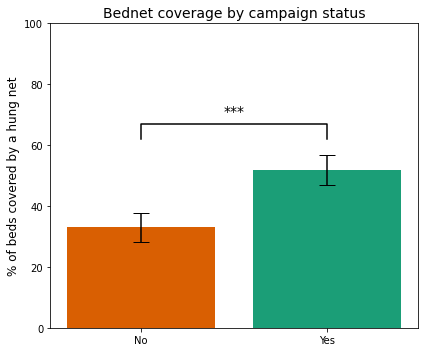

In [201]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# --- Load and clean your data ---
dff = pd.read_csv('/Users/emretoner/Desktop/surveyresults.csv')

# Rename relevant columns
dff = dff.rename(columns={
    "Has your Subprefecture completed a mosquito net distribution campaign?\nVotre sous-préfecture a-t-elle réalisé une campagne de distribution de moustiquaires ?": "campaign",
    "How many beds or sleeping areas are there in your household?\nCombien de lits ou couchettes y a- il dans votre maison?": "#beds",
    "Total number of nets hung / Nombre total de moustiquaires suspendues:": "nets_hung"
})

# Keep only relevant columns
dff = dff[["campaign", "#beds", "nets_hung"]].dropna()

# Ensure numeric
dff["#beds"] = pd.to_numeric(dff["#beds"], errors="coerce")
dff["nets_hung"] = pd.to_numeric(dff["nets_hung"], errors="coerce")

# --- Coverage calculation (population-weighted) ---
dff["covered_beds"] = dff[["nets_hung", "#beds"]].min(axis=1)

grouped = dff.groupby("campaign").agg(
    total_beds=("#beds", "sum"),
    covered_beds=("covered_beds", "sum")
)

counts = grouped["covered_beds"].values   # successes
nobs = grouped["total_beds"].values       # total trials

coverage_by_campaign = (counts / nobs) * 100
print("Coverage by campaign (% of beds covered):")
for camp, cov in zip(grouped.index, coverage_by_campaign):
    print(f"{camp}: {cov:.1f}%")

print("\n--- Statistical Analysis ---")

# Z-test
stat, pval = proportions_ztest(count=counts, nobs=nobs)
print("Counts (covered beds):", counts)
print("Total beds:", nobs)
print(f"Z-statistic: {stat:.3f}, p-value: {pval:.5f}")

# 95% Confidence Intervals for each group
cis = [proportion_confint(counts[i], nobs[i], alpha=0.05, method="normal") for i in range(len(counts))]
for i, group in enumerate(grouped.index):
    ci_low, ci_high = cis[i]
    print(f"{group} coverage: {counts[i]}/{nobs[i]} = {counts[i]/nobs[i]*100:.1f}% "
          f"(95% CI: {ci_low*100:.1f}% – {ci_high*100:.1f}%)")

# CI for the difference
p1, p2 = counts[0]/nobs[0], counts[1]/nobs[1]
diff = p2 - p1
se_diff = np.sqrt(p1*(1-p1)/nobs[0] + p2*(1-p2)/nobs[1])
ci_low, ci_high = diff - 1.96*se_diff, diff + 1.96*se_diff
print(f"\nDifference in coverage (Yes - No): {diff*100:.1f}% "
      f"(95% CI: {ci_low*100:.1f}% – {ci_high*100:.1f}%)")

# --- Visualization ---
props_pct = coverage_by_campaign
ci_lows = [ci[0]*100 for ci in cis]
ci_highs = [ci[1]*100 for ci in cis]
error_bars = [props_pct - np.array(ci_lows), np.array(ci_highs) - props_pct]

fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(grouped.index, props_pct, yerr=error_bars, capsize=8, color=["#d95f02", "#1b9e77"])

ax.set_ylabel("% of beds covered by a hung net", fontsize=12)
ax.set_title("Bednet coverage by campaign status", fontsize=14)
ax.set_ylim(0, 100)


# --- Significance stars ---
if pval < 0.001:
    stars = "***"
elif pval < 0.01:
    stars = "**"
elif pval < 0.05:
    stars = "*"
else:
    stars = "ns"

# Bracket between bars
x1, x2 = 0, 1   # indices of bars
y, h = max(props_pct) + 10, 5  # height placement
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
ax.text((x1+x2)*0.5, y+h+2, stars, ha="center", va="bottom", fontsize=14)
desktop_path = os.path.expanduser('~/Desktop/bedscovered.png')
plt.savefig(desktop_path, facecolor='white', dpi=300)
plt.tight_layout()
plt.show()



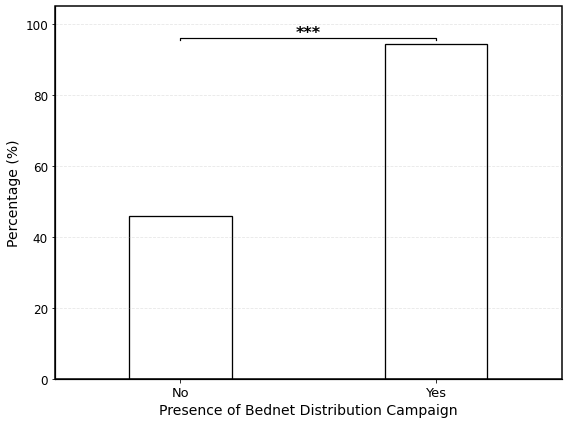

Chi-squared test results:
Chi² = 76.69, p-value = 0.0000


In [202]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import pandas as pd
import matplotlib.patches as patches
import os

# Example summary_df (replace with your own data)
# summary_df = pd.DataFrame({
#     "campaign": ["No", "Yes"],
#     "Metric": ["Net Ownership (%)", "Net Ownership (%)"],
#     "Percentage": [45.8, 94.5]
# })

# Chi-squared test
contingency = pd.crosstab(df['campaign'], df['has_nets'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

# Significance stars
if p_value < 0.001:
    stars = '***'
elif p_value < 0.01:
    stars = '**'
elif p_value < 0.05:
    stars = '*'
else:
    stars = ''

# --- Figure setup ---
plt.figure(figsize=(8, 6))
fig = plt.gcf()
fig.patch.set_facecolor('white')

# --- Monochrome barplot ---
ax = sns.barplot(
    data=summary_df,
    x="campaign",
    y="Percentage",
    edgecolor='black',
    linewidth=1.3,
    color='white',
    dodge=False
)

# --- Make bars thinner manually ---
for patch in ax.patches:
    x, y = patch.get_xy()
    width = patch.get_width()
    patch.set_x(x + width * 0.25)
    patch.set_width(width * 0.5)
    patch.set_facecolor('white')
    patch.set_edgecolor('black')
    patch.set_linewidth(1.3)

# --- Add significance bar + stars ---
y_max = summary_df["Percentage"].max()
x1, x2 = 0, 1

plt.plot([x1, x1, x2, x2],
         [y_max + 1, y_max + 1.5, y_max + 1.5, y_max + 1],
         lw=1.2, c='black')

plt.text((x1 + x2) / 2, y_max + 1.1, stars,
         ha='center', va='bottom', fontsize=16,
         fontweight='bold', color='black')

# --- Styling (same as boxplot figure) ---
ax.tick_params(axis='x', colors='black', labelsize=13)
ax.tick_params(axis='y', colors='black', labelsize=12)
ax.set_xlabel("Presence of Bednet Distribution Campaign", fontsize=14, color='black')
ax.set_ylabel("Percentage (%)", fontsize=14, color='black')

# Ensure “No” and “Yes” labels match the same font look
ax.set_xticklabels(ax.get_xticklabels(), fontsize=13, color='black')

# --- Add full boundary box ---
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

rect = patches.Rectangle(
    (0, 0), 1, 1,
    transform=ax.transAxes,
    fill=False,
    color='black',
    lw=1.5,
    clip_on=False
)
ax.add_patch(rect)

# --- Clean gridlines and remove legend ---
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=False, bottom=False)

plt.ylim(0, 105)
plt.tight_layout()

# Save to Desktop
# desktop_path = os.path.expanduser('~/Desktop/netownership_bw_matched_fonts.png')
# plt.savefig(desktop_path, facecolor='white', dpi=300, bbox_inches='tight')
plt.show()

print("Chi-squared test results:")
print(f"Chi² = {chi2:.2f}, p-value = {p_value:.4f}")



In [177]:
summary_df

,campaign,Metric,Percentage
0,No,Net Ownership (%),45.789474
1,Yes,Net Ownership (%),94.531250


In [170]:
import pandas as pd

# Rename the columns
df = df.rename(columns={
    "How many pregnant women live in the house?\nCombien de femmes enceintes vivent dans la maison ?": "#_pregnant",
    "Last night, how many pregnant women in your family slept under a mosquito net?\nHier soir, combien de femmes enceintes de votre famille ont dormi sous une moustiquaire ?": "pregnant_sleep"
})

# Drop rows with NA in #_pregnant or pregnant_sleep and make a copy to avoid warnings
df_clean = df.dropna(subset=["#_pregnant", "pregnant_sleep"]).copy()

# Convert columns to numeric safely
df_clean.loc[:, "#_pregnant"] = pd.to_numeric(df_clean["#_pregnant"], errors="coerce")
df_clean.loc[:, "pregnant_sleep"] = pd.to_numeric(df_clean["pregnant_sleep"], errors="coerce")

# Drop again in case conversion produced NaNs
df_clean = df_clean.dropna(subset=["#_pregnant", "pregnant_sleep"])

# Calculate percentage
total_pregnant = df_clean["#_pregnant"].sum()
total_slept = df_clean["pregnant_sleep"].sum()

percent_slept = (total_slept / total_pregnant) * 100 if total_pregnant > 0 else 0

print(f"Percent of pregnant women who slept under a net: {percent_slept:.2f}%")


Percent of pregnant women who slept under a net: 41.67%


<ipython-input-170-1cc9713bb5dd>:14: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_clean.loc[:, "pregnant_sleep"] = pd.to_numeric(df_clean["pregnant_sleep"], errors="coerce")


In [22]:
from scipy.stats import shapiro

# Test for normality in one group
shapiro(df[df["campaign"] == "No"]["# of nets"].dropna())

ShapiroResult(statistic=0.7116036415100098, pvalue=9.096579642500775e-18)

In [23]:
shapiro(df[df["campaign"] == "Yes"]["# of nets"].dropna())

ShapiroResult(statistic=0.9292579889297485, pvalue=4.6070713324297685e-06)

<AxesSubplot:xlabel='# of nets', ylabel='Count'>

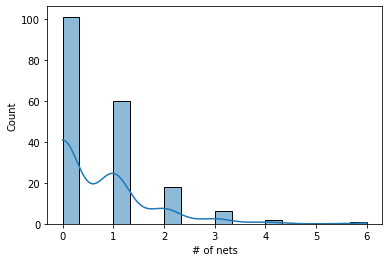

In [24]:
import seaborn as sns
sns.histplot(df[df["campaign"] == "No"]["# of nets"], kde=True)

<AxesSubplot:xlabel='# of nets', ylabel='Count'>

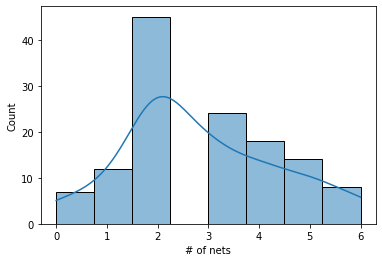

In [25]:
sns.histplot(df[df["campaign"] == "Yes"]["# of nets"], kde=True)

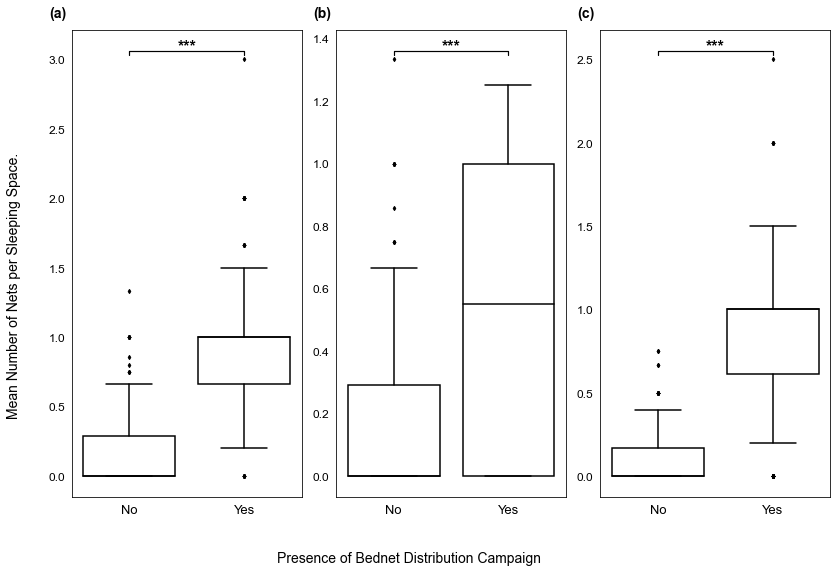

In [115]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import os

# List of numeric columns to test
numeric_cols = ["# of nets", "# nets hung", "# free distribution"]

# Fill NaN values with 0 for numeric columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Normalize by #beds
for col in numeric_cols:
    df[f"{col}_per_bed"] = df[col] / df["#beds"]

# Figure setup
plt.figure(figsize=(12, 8))
fig = plt.gcf()
fig.patch.set_facecolor('white')

subplot_labels = ['(a)', '(b)', '(c)']

for idx, col in enumerate(numeric_cols, 1):
    adjusted_col = f"{col}_per_bed"

    group_yes = df[df["campaign"] == "Yes"][adjusted_col].dropna()
    group_no = df[df["campaign"] == "No"][adjusted_col].dropna()

    # Remove highest outlier from each group (optional for clarity)
    if len(group_yes) > 1:
        group_yes = group_yes[group_yes != group_yes.max()]
    if len(group_no) > 1:
        group_no = group_no[group_no != group_no.max()]

    # Mann–Whitney U test
    stat, p = mannwhitneyu(group_yes, group_no, alternative="two-sided")

    # --- Subplot ---
    ax = plt.subplot(1, 3, idx)
    ax.set_facecolor('white')

    # Combined DataFrame for plotting
    plot_data = pd.concat([
        pd.DataFrame({"campaign": "Yes", adjusted_col: group_yes}),
        pd.DataFrame({"campaign": "No", adjusted_col: group_no})
    ])

    # --- Boxplot (black-and-white aesthetic) ---
    sns.boxplot(
        data=plot_data,
        x="campaign",
        y=adjusted_col,
        ax=ax,
        order=["No", "Yes"],
        showcaps=True,
        boxprops={'facecolor': 'white', 'edgecolor': 'black'},
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        flierprops={'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 3}
    )

    # --- Axis styling ---
    ax.tick_params(axis='x', colors='black', labelsize=13)
    ax.tick_params(axis='y', colors='black', labelsize=12)
    for spine in ax.spines.values():
        spine.set_color('black')

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.text(-0.1, 1.05, subplot_labels[idx-1], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left', color='black')

    # --- Significance bar and stars ---
    if p <= 0.001:
        stars = '***'
    elif p <= 0.01:
        stars = '**'
    elif p <= 0.05:
        stars = '*'
    else:
        stars = ''

    if stars:
        y_max = max(group_yes.max(), group_no.max())
        # Slightly above the top box, but still within the plot area
        line_y = y_max * 1.02  
        tick_height = y_max * 0.01  

        # Draw connecting significance line
        ax.plot([0, 0, 1, 1], [line_y - tick_height, line_y, line_y, line_y - tick_height],
                color='black', linewidth=1.2)

        # Place stars just above the line, still inside the frame
        ax.text(0.5, line_y - tick_height * 0.5, stars, ha='center', va='bottom',
                color='black', fontsize=16, fontweight='bold')

# Adjust layout
plt.tight_layout(rect=[0.07, 0.08, 1, 1])

# Shared labels
fig.text(0.5, 0.02, "Presence of Bednet Distribution Campaign", ha='center', fontsize=14, color='black')
fig.text(0.035, 0.5, "Mean Number of Nets per Sleeping Space.", va='center', rotation='vertical', fontsize=14, color='black')

# Save
desktop_path = os.path.expanduser('~/Desktop/bednetfinal_bw_boxplots.png')
# plt.savefig(desktop_path, facecolor='white', dpi=300)
plt.show()


In [116]:
# --- SUMMARY STATISTICS FOR BOXPLOTS ---
print("--- SUMMARY STATISTICS (Nets per Bed) ---")
stats_list = []

for col in numeric_cols:
    adjusted_col = f"{col}_per_bed"
    
    for camp in ["No", "Yes"]:
        # Match the filtering used in the plot (including outlier removal if you kept it)
        data = df[df["campaign"] == camp][adjusted_col].dropna()
        if len(data) > 1:
            data = data[data != data.max()] # Match the outlier removal in your loop
            
        stats_list.append({
            "Metric": col,
            "Campaign": camp,
            "N": len(data),
            "Median": data.median(),
            "Q1": data.quantile(0.25),
            "Q3": data.quantile(0.75),
            "Max": data.max()
        })

stats_df = pd.DataFrame(stats_list)
print(stats_df.to_string(index=False))

# Calculate the "Effect Size" for the manuscript
for col in numeric_cols:
    m_no = stats_df[(stats_df["Metric"] == col) & (stats_df["Campaign"] == "No")]["Median"].values[0]
    m_yes = stats_df[(stats_df["Metric"] == col) & (stats_df["Campaign"] == "Yes")]["Median"].values[0]
    increase = m_yes - m_no
    print(f"\n{col}: Median increase of {increase:.2f} nets per bed.")

--- SUMMARY STATISTICS (Nets per Bed) ---
             Metric Campaign   N  Median       Q1       Q3      Max
          # of nets       No 187    0.00 0.000000 0.291667 1.333333
          # of nets      Yes 127    1.00 0.666667 1.000000 3.000000
        # nets hung       No 187    0.00 0.000000 0.291667 1.333333
        # nets hung      Yes 124    0.55 0.000000 1.000000 1.250000
# free distribution       No 187    0.00 0.000000 0.166667 0.750000
# free distribution      Yes 127    1.00 0.612500 1.000000 2.500000

# of nets: Median increase of 1.00 nets per bed.

# nets hung: Median increase of 0.55 nets per bed.

# free distribution: Median increase of 1.00 nets per bed.


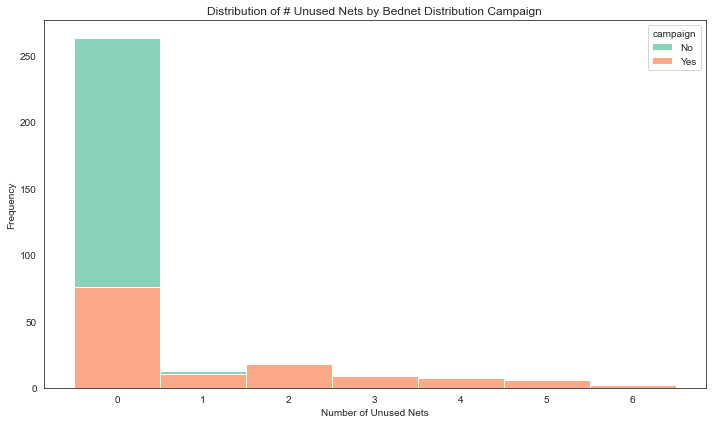

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure that missing values are filled
df["# unused"] = df["# unused"].fillna(0)

# Plot histogram with discrete bins for the '# unused' variable
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="# unused", hue="campaign", kde=False, discrete=True, 
             palette="Set2", multiple="stack", bins=range(int(df["# unused"].min()), int(df["# unused"].max()) + 2))

# Add labels
plt.xlabel("Number of Unused Nets")
plt.ylabel("Frequency")
plt.title("Distribution of # Unused Nets by Bednet Distribution Campaign")

# Show the plot
plt.tight_layout()
plt.show()

In [100]:
# Ensure columns are numeric
df["under_5_lastnight"] = pd.to_numeric(df["under_5_lastnight"], errors="coerce")
df["total_under_5"] = pd.to_numeric(df["total_under_5"], errors="coerce")

# Filter for rows where the number of children under nets is greater than the total number of children under 5
problematic_rows = df[df["under_5_lastnight"] > df["total_under_5"]]

# Display the relevant columns, including volunteer name
result = problematic_rows[["Volunteer Name\nNom du Volontaire", "under_5_lastnight", "total_under_5"]]
print(result)

     Volunteer Name\nNom du Volontaire  under_5_lastnight  total_under_5
27    Ben plato/Amadou dioulde diallo                 2.0            1.0
38              Ben Plato/Diallo hady                 2.0            1.0
97    Ben plato/Amadou dioulde diallo                 1.0            0.0
99    Ben plato/Amadou dioulde diallo                 4.0            2.0
110     Ben Plato/ Alpha Oumar Camara                 2.0            1.0
114   Ben plato/Amadou dioulde diallo                 2.0            1.0
122                      Dirk Chisholm                9.0            1.0
157                      Caroline Read                2.0            0.0
158                      Caroline Read                2.0            0.0
159                      Caroline Read                3.0            2.0
160                      Caroline Read                3.0            2.0
178                         Emre Toner                4.0            3.0
208  Ben Plato/Fatoumata Diaraye Kante             

In [101]:
total_inconsistencies = (df["under_5_lastnight"] > df["total_under_5"]).sum()
print("Total inconsistencies:", total_inconsistencies)

Total inconsistencies: 30


In [102]:
# Drop rows with inconsistent under-5 data
df1 = df[df["under_5_lastnight"] <= df["total_under_5"]]

In [103]:
men_col = "Last night, how many men in your family slept under a mosquito net?\nHier soir, combien d'hommes de votre famille ont dormi sous une moustiquaire ?"
women_col = "Last night, how many women in your family slept under a mosquito net?\nHier soir, combien de femmes de votre famille ont dormi sous une moustiquaire ?"
adults_total_col = "total_adult_house"

# --- Create new variables ---
df["total_adults_slept"] = df[[men_col, women_col]].sum(axis=1, skipna=True)
df["total_adults"] = df[adults_total_col]

In [104]:
total_inconsistencies = (df["total_adults_slept"] > df["total_adults"]).sum()
print("Total inconsistencies:", total_inconsistencies)

Total inconsistencies: 58


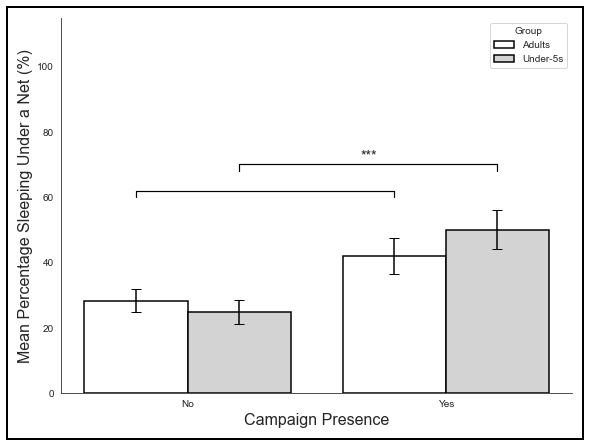


--- FINAL CLEANED RESULTS ---
Campaign    Group      Mean      SEM
      No   Adults 28.272602 3.458535
     Yes   Adults 41.969697 5.471153
      No Under-5s 24.782609 3.644079
     Yes Under-5s 50.000000 6.021631

Adult P-value: 0.05246
Under-5 P-value: 0.00086


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib.patches as patches
import os

# 1. PRE-CLEANING: Ensure numeric types and handle initial inconsistencies
df["under_5_lastnight"] = pd.to_numeric(df["under_5_lastnight"], errors="coerce")
df["total_under_5"] = pd.to_numeric(df["total_under_5"], errors="coerce")

men_col = "Last night, how many men in your family slept under a mosquito net?\nHier soir, combien d'hommes de votre famille ont dormi sous une moustiquaire ?"
women_col = "Last night, how many women in your family slept under a mosquito net?\nHier soir, combien de femmes de votre famille ont dormi sous une moustiquaire ?"
adults_total_col = "total_adult_house"

# Create helper columns
df["total_adults_slept"] = df[[men_col, women_col]].sum(axis=1, skipna=True)
df["total_adults"] = pd.to_numeric(df[adults_total_col], errors="coerce")

# 2. THE UNIFIED FILTER: This removes outliers that were flattening your means
# We only keep rows where the count of people under nets is <= total people
df_final = df[
    (df["under_5_lastnight"] <= df["total_under_5"]) & 
    (df["total_adults_slept"] <= df["total_adults"])
].copy()

# 3. PERCENTAGE CALCULATION
# Using the unified df_final ensures Adults and Under-5s are from the same household pool
df_final["percentage_adults"] = np.where(df_final["total_adults"] > 0,
                                         (df_final["total_adults_slept"] / df_final["total_adults"]) * 100,
                                         np.nan)

df_final["percentage_underfive"] = np.where(df_final["total_under_5"] > 0,
                                            (df_final["under_5_lastnight"] / df_final["total_under_5"]) * 100,
                                            np.nan)

# Drop any rows that still have NaNs in key categories
df_final = df_final.dropna(subset=["percentage_adults", "percentage_underfive", "campaign"])

# 4. STATISTICAL TESTING
adult_yes = df_final[df_final["campaign"]=="Yes"]["percentage_adults"]
adult_no = df_final[df_final["campaign"]=="No"]["percentage_adults"]
stat_adult, p_adult = mannwhitneyu(adult_yes, adult_no, alternative='two-sided')

child_yes = df_final[df_final["campaign"]=="Yes"]["percentage_underfive"]
child_no = df_final[df_final["campaign"]=="No"]["percentage_underfive"]
stat_child, p_child = mannwhitneyu(child_yes, child_no, alternative='two-sided')

def pvalue_to_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

# 5. PREPARE PLOT DATAFRAME
adult_stats = df_final.groupby("campaign")["percentage_adults"].agg(['mean','sem']).reset_index()
child_stats = df_final.groupby("campaign")["percentage_underfive"].agg(['mean','sem']).reset_index()

plot_df = pd.DataFrame({
    "Campaign": ["No", "Yes", "No", "Yes"],
    "Group": ["Adults", "Adults", "Under-5s", "Under-5s"],
    "Mean": [
        adult_stats.loc[adult_stats["campaign"]=="No", "mean"].values[0],
        adult_stats.loc[adult_stats["campaign"]=="Yes", "mean"].values[0],
        child_stats.loc[child_stats["campaign"]=="No", "mean"].values[0],
        child_stats.loc[child_stats["campaign"]=="Yes", "mean"].values[0]
    ],
    "SEM": [
        adult_stats.loc[adult_stats["campaign"]=="No", "sem"].values[0],
        adult_stats.loc[adult_stats["campaign"]=="Yes", "sem"].values[0],
        child_stats.loc[child_stats["campaign"]=="No", "sem"].values[0],
        child_stats.loc[child_stats["campaign"]=="Yes", "sem"].values[0]
    ]
})

# 6. VISUALIZATION
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')

# Set colors for publication (White and Light Grey)
sns.barplot(data=plot_df, x="Campaign", y="Mean", hue="Group",
            palette=["#FFFFFF", "#D3D3D3"], edgecolor='black', linewidth=1.5, ax=ax)

# Add Error Bars manually to ensure alignment with hue
for i, row in plot_df.iterrows():
    # Adjust x-position for hue offset
    x_base = 0 if row["Campaign"] == "No" else 1
    x_offset = -0.2 if row["Group"] == "Adults" else 0.2
    ax.errorbar(x=x_base + x_offset, y=row["Mean"], yerr=row["SEM"], 
                fmt='none', c='black', capsize=5, lw=1.5)

# 7. SIGNIFICANCE ANNOTATIONS
# Placing brackets dynamically
y_top = plot_df["Mean"].max() + 10

# Adult bracket
ax.plot([-0.2, -0.2, 0.8, 0.8], [y_top, y_top+2, y_top+2, y_top], lw=1.2, c='black')
ax.text(0.3, y_top+2.5, pvalue_to_stars(p_adult), ha='center', va='bottom', fontsize=14)

# Under-5s bracket
ax.plot([0.2, 0.2, 1.2, 1.2], [y_top+8, y_top+10, y_top+10, y_top+8], lw=1.2, c='black')
ax.text(0.7, y_top+10.5, pvalue_to_stars(p_child), ha='center', va='bottom', fontsize=14)

# Styling
ax.set_ylabel("Mean Percentage Sleeping Under a Net (%)", fontsize=16)
ax.set_xlabel("Campaign Presence", fontsize=16)
ax.set_ylim(0, 115)
sns.despine()

# Add outer boundary for professional look
rect = patches.Rectangle((0,0), 1, 1, transform=fig.transFigure,
                         facecolor='none', edgecolor='black', linewidth=2)
fig.patches.append(rect)

plt.tight_layout()
desktop_path = os.path.expanduser('~/Desktop/adult_child_bednet_sidebyside_bw_boundary.png')
plt.savefig(desktop_path, facecolor='white', dpi=300)  
plt.show()

# 8. PRINT FINAL SUMMARY FOR MANUSCRIPT
print("\n--- FINAL CLEANED RESULTS ---")
print(plot_df.to_string(index=False))
print(f"\nAdult P-value: {p_adult:.5f}")
print(f"Under-5 P-value: {p_child:.5f}")

In [107]:
# --- Extracting Sample Sizes (N) ---
print("--- Final Sample Sizes (N) ---")

# Counts for Adults (Campaign: No vs Yes)
adult_n = df_final.groupby('campaign')['percentage_adults'].count()
print(f"Adults (No Campaign): N = {adult_n['No']}")
print(f"Adults (Yes Campaign): N = {adult_n['Yes']}")

# Counts for Under-5s (Campaign: No vs Yes)
child_n = df_final.groupby('campaign')['percentage_underfive'].count()
print(f"Under-5s (No Campaign): N = {child_n['No']}")
print(f"Under-5s (Yes Campaign): N = {child_n['Yes']}")

# Total households used in this specific analysis
print(f"\nTotal unique households analyzed: {len(df_final)}")

--- Final Sample Sizes (N) ---
Adults (No Campaign): N = 115
Adults (Yes Campaign): N = 66
Under-5s (No Campaign): N = 115
Under-5s (Yes Campaign): N = 66

Total unique households analyzed: 181


Total nets from each source by campaign group:

          # from clinic  # purchased  # other  # free distribution
campaign                                                          
No                 51.0          0.0      1.0                 46.0
Yes                49.0          1.0      2.0                251.0

Percentage contribution of each source to total nets per campaign:

          # from clinic  # purchased  # other  # free distribution
campaign                                                          
No                52.04         0.00     1.02                46.94
Yes               16.17         0.33     0.66                82.84


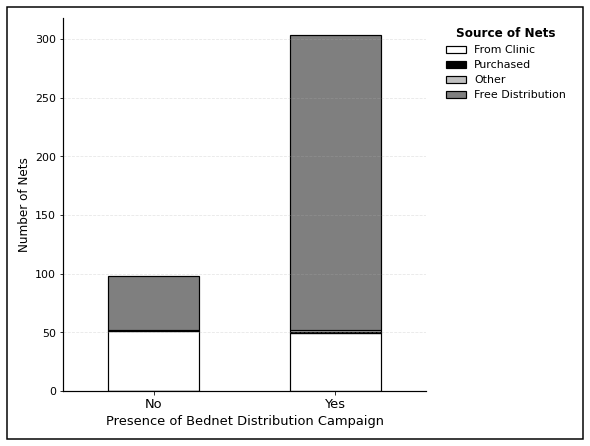

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import os

# --- Aggregate sums of net sources by campaign group ---
source_cols = ["# from clinic", "# purchased", "# other", "# free distribution"]
summary = df.groupby("campaign")[source_cols].sum()

# --- Calculate total nets per campaign ---
summary["total_nets"] = summary.sum(axis=1)

# --- Calculate percentage contribution of each source per campaign ---
percentages = summary[source_cols].div(summary["total_nets"], axis=0) * 100

# --- Print summaries ---
print("Total nets from each source by campaign group:\n")
print(summary[source_cols])
print("\nPercentage contribution of each source to total nets per campaign:\n")
print(percentages.round(2))

# --- Clean legend labels (remove #) ---
clean_labels = ["From Clinic", "Purchased", "Other", "Free Distribution"]

# --- Distinct grayscale palette ---
# Ordered from lightest to darkest for clarity
colors = ["white", "black", "#C0C0C0", "#7F7F7F"]

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('white')

# --- Stacked bar plot ---
summary[source_cols].plot(
    kind='bar',
    stacked=True,
    color=colors,
    edgecolor='black',
    linewidth=1.2,
    ax=ax
)

# --- Axis labels and ticks ---
ax.set_ylabel("Number of Nets", fontsize=12, color='black')
ax.set_xlabel("Presence of Bednet Distribution Campaign", fontsize=13, color='black')
ax.set_xticklabels(["No", "Yes"], rotation=0, fontsize=13, color='black')
ax.tick_params(axis='y', labelsize=11, colors='black')

# --- Legend (move right, no border, clean text) ---
legend = ax.legend(
    clean_labels,
    title="Source of Nets",
    bbox_to_anchor=(1.03, 1),
    loc='upper left',
    frameon=False
)
plt.setp(legend.get_texts(), color='black', fontsize=11)
legend.get_title().set_fontsize(12)
legend.get_title().set_weight('bold')
legend.get_title().set_color('black')

# --- Remove title ---
ax.set_title("")

# --- Style: border + grid ---
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=False, bottom=False)

# --- Add full outer boundary box (visible in saved figure) ---
rect = patches.Rectangle(
    (0, 0), 1, 1,
    transform=fig.transFigure,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5,
    zorder=1000
)
fig.patches.append(rect)

plt.tight_layout()

# # --- Save ---
# desktop_path = os.path.expanduser('~/Desktop/sourcenets_bw_boxed.png')
# plt.savefig(desktop_path, facecolor='white', bbox_inches='tight', dpi=300)
plt.show()


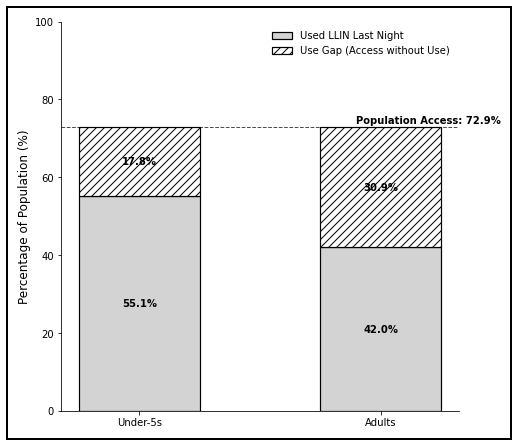

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as patches

# --- Data for 'Campaign: Yes' Group ---
# Based on your results: 72.9% had access. 
# Use was 55.1% for Children and 42.0% for Adults.

labels = ['Under-5s', 'Adults']
use_values = [55.1, 42.0]
access_value = 72.9
gap_values = [access_value - x for x in use_values]

# --- Plot Setup ---
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')

width = 0.5  # Bar width

# 1. Plot the 'Use' (The bottom part of the stack)
ax.bar(labels, use_values, width, label='Used LLIN Last Night', 
       color='lightgrey', edgecolor='black', linewidth=1.2)

# 2. Plot the 'Gap' (The top part of the stack, starting where Use ends)
ax.bar(labels, gap_values, width, bottom=use_values, label='Use Gap (Access without Use)', 
       color='white', edgecolor='black', linewidth=1.2, hatch='///')

# 3. Add a horizontal dashed line for Population Access (The 'Target')
ax.axhline(y=access_value, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.text(1.5, access_value + 1, f'Population Access: {access_value}%', 
        ha='right', fontsize=10, fontweight='bold')

# --- Formatting ---
ax.set_ylabel("Percentage of Population (%)", fontsize=12)
# ax.set_title("Figure 2. LLIN Use Gap Among Households with Campaign Access", 
#              fontsize=13, fontweight='bold', pad=20)
ax.set_ylim(0, 100)

# Add value labels inside the bars
for i in range(len(labels)):
    # Label for Use
    ax.text(i, use_values[i]/2, f'{use_values[i]}%', ha='center', va='center', 
            fontweight='bold', color='black')
    # Label for Gap
    ax.text(i, use_values[i] + gap_values[i]/2, f'{gap_values[i]:.1f}%', 
            ha='center', va='center', fontweight='bold', color='black')

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', frameon=False)

# --- Outer boundary rectangle (Matching your previous style) ---
rect = patches.Rectangle((0,0), 1, 1, transform=fig.transFigure,
                         facecolor='none', edgecolor='black', linewidth=2, zorder=1000)
fig.patches.append(rect)
desktop_path = os.path.expanduser('~/Desktop/usegapgraph.png')
plt.savefig(desktop_path, facecolor='white', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

In [207]:
# --- Identify and remove invalid / inconsistent data ---
df[men_col] = pd.to_numeric(df[men_col], errors='raise')
df[women_col] = pd.to_numeric(df[women_col], errors='raise')
df[adults_total_col] = pd.to_numeric(df[adults_total_col], errors='raise')

# Create derived columns
df1["total_adults_slept"] = df[[men_col, women_col]].sum(axis=1, skipna=True)
df1["total_adults"] = df[adults_total_col]

# Find and count invalid rows (more slept than total)
invalid_rows = df1[df1["total_adults_slept"] > df1["total_adults"]]
print(f"⚠️ Invalid rows (slept > total): {len(invalid_rows)}")

# Drop those invalid rows
df2 = df1[df1["total_adults_slept"] <= df1["total_adults"]]

# Drop rows where total adults is 0 or missing
zero_or_missing = df2[(df2["total_adults"].isna()) | (df2["total_adults"] == 0)]
print(f"⚠️ Rows with total_adults = 0 or missing: {len(zero_or_missing)}")

df3 = df2[df2["total_adults"].notna() & (df2["total_adults"] > 0)]

# --- Compute percentage ---
df3["percentage_adults"] = (df3["total_adults_slept"] / df3["total_adults"]) * 100

# Drop rows missing campaign or percentage
before_drop = len(df3)
df_clean = df3.dropna(subset=["percentage_adults", "campaign"])
print(f"✅ Dropped {before_drop - len(df_clean)} rows due to NaNs in key variables.")


⚠️ Invalid rows (slept > total): 42
⚠️ Rows with total_adults = 0 or missing: 2
✅ Dropped 0 rows due to NaNs in key variables.


<ipython-input-207-ac5506afc9e1>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["total_adults_slept"] = df[[men_col, women_col]].sum(axis=1, skipna=True)
<ipython-input-207-ac5506afc9e1>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["total_adults"] = df[adults_total_col]
<ipython-input-207-ac5506afc9e1>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

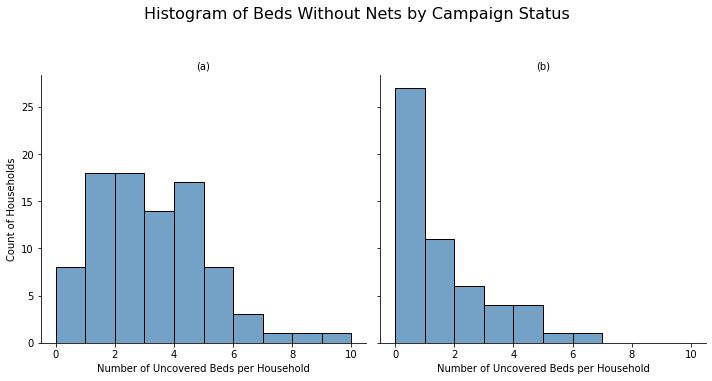

In [339]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new column with facet labels (a) and (b)
label_map = {'No': '(a)', 'Yes': '(b)'}
df['campaign_label'] = df['campaign'].map(label_map)

# Calculate number of uncovered beds per household
df['uncovered_beds'] = df['#beds'] - df['# nets hung']
df['uncovered_beds'] = df['uncovered_beds'].clip(lower=0)  # No negative numbers

# Define max bins for histogram range
max_bins = int(df['uncovered_beds'].max())

# Create FacetGrid with updated labels
g = sns.FacetGrid(df, col="campaign_label", height=5, aspect=1)
g.map_dataframe(
    sns.histplot,
    x="uncovered_beds",
    bins=range(0, max_bins + 2),
    color="steelblue",
    kde=False
)

# Set axis labels and titles
g.set_axis_labels("Number of Uncovered Beds per Household", "Count of Households")
g.set_titles(col_template="{col_name}")

plt.suptitle("Histogram of Beds Without Nets by Campaign Status", y=1.05, fontsize=16)
plt.tight_layout()
# Save to Desktop
# desktop_path = os.path.expanduser('~/Desktop/histogrambedswithoutnets.png')
# plt.savefig(desktop_path, facecolor='white', dpi=300)
plt.show()



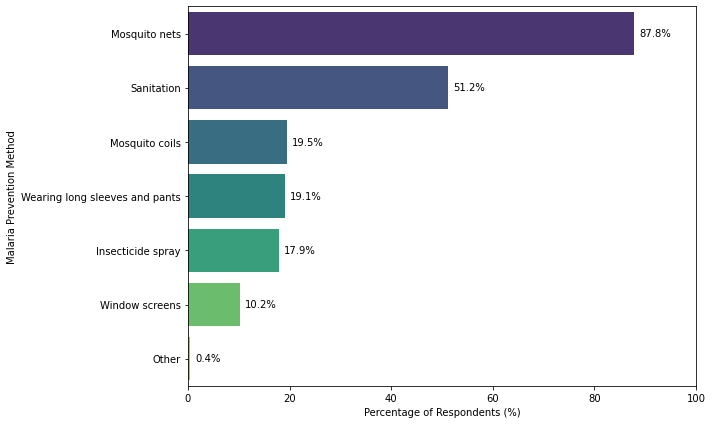

In [340]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Column name
col = "What are the methods of prevention in the fight against malaria?\nQuels sont les moyens de prévention de lutte contre le paludisme ?"

# Drop NA rows
df_clean = df[[col]].dropna().copy()

# Regex to extract all full English methods before the slash
pattern = r'\d+\.\s*([^/]+)'

all_methods = []
for response in df_clean[col]:
    matches = re.findall(pattern, response)
    cleaned = [m.strip() for m in matches]
    all_methods.extend(cleaned)

# Frequency and percentage
method_counts = pd.Series(all_methods).value_counts()
total_respondents = len(df_clean)
method_percentages = (method_counts / total_respondents * 100).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=method_percentages.values, y=method_percentages.index, palette="viridis")

plt.xlabel("Percentage of Respondents (%)")
plt.ylabel("Malaria Prevention Method")
plt.title("")  # Leave blank for journal-style figure
plt.xlim(0, 100)

# Annotate bars
for i, (value, label) in enumerate(zip(method_percentages.values, method_percentages.index)):
    plt.text(value + 1, i, f"{value:.1f}%", va='center')

    # Save to Desktop
desktop_path = os.path.expanduser('~/Desktop/knowledge.png')
# plt.savefig(desktop_path, facecolor='white', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [164]:
# Clean column name
df = df.rename(columns={
    "If yes, may I see your mosquito net?\nSi oui, est-ce que je peux voir votre moustiquaire ?": "net_seen"
})

# Drop missing values
net_seen_clean = df["net_seen"].dropna()

# Calculate value counts and percentages
net_seen_counts = net_seen_clean.value_counts(normalize=True) * 100

# Print result
for response, percent in net_seen_counts.items():
    print(f"{response}: {percent:.1f}%")


Yes/Oui: 79.9%
No/Non: 20.1%


In [5]:
import pandas as pd

# 1. Define the data based on your specific results
# Note: n values derived from your manuscript (153 non-campaign, 103 campaign)
data = {
    "Indicator": [
        "Household ownership (≥1 LLIN)",
        "Population Access",
        "Mean Nets per Bed",
        "Mean Nets Hung per Bed",
        "Net Use (Children < 5)",
        "Net Use (Adults)"
    ],
    "No Campaign (n=153)": [
        "45.8%", 
        "20.8%", 
        "0.19 (±0.3)", 
        "0.18 (±0.2)", 
        "35.8%", 
        "29.3%"
    ],
    "Campaign (n=103)": [
        "94.5%", 
        "72.9%", 
        "0.98 (±0.6)", 
        "0.50 (±0.4)", 
        "55.1%", 
        "42.0%"
    ],
    "p-value": [
        "< 0.001",
        "< 0.001",
        "< 0.001",
        "< 0.001",
        "0.004",
        "0.013"
    ]
}

# 2. Create DataFrame
df = pd.DataFrame(data)

# 3. Apply Professional Styling (Standard Medical Journal Format)
def render_journal_table(df):
    styled = df.style.set_properties(**{
        'text-align': 'left',
        'font-family': 'Arial',
        'border-collapse': 'collapse'
    }).set_table_styles([
        # Top border (Thick)
        {'selector': 'thead', 'props': [('border-top', '2px solid black'), ('border-bottom', '1px solid black')]},
        # Bottom border (Thick)
        {'selector': 'tbody tr:last-child', 'props': [('border-bottom', '2px solid black')]},
        # Bold the p-values for significance
        {'selector': 'td', 'props': [('padding', '8px')]}
    ]).hide(axis='index')
    
    return styled

# Display the styled table
df_styled = render_journal_table(df)
df_styled

Indicator,No Campaign (n=153),Campaign (n=103),p-value
Household ownership (≥1 LLIN),45.8%,94.5%,< 0.001
Population Access,20.8%,72.9%,< 0.001
Mean Nets per Bed,0.19 (±0.3),0.98 (±0.6),< 0.001
Mean Nets Hung per Bed,0.18 (±0.2),0.50 (±0.4),< 0.001
Net Use (Children < 5),35.8%,55.1%,0.004
Net Use (Adults),29.3%,42.0%,0.013


In [7]:
import dataframe_image as dfi
import os

import os
import dataframe_image as dfi

# Expand the path to your Desktop
desktop_path = os.path.expanduser('~/Desktop/table1.png')

# Use 'matplotlib' as the engine to avoid the asyncio/Playwright error
dfi.export(df_styled, desktop_path, table_conversion='matplotlib', dpi=300)